# 06b — Extended Feature Analysis

Picks up from `06_features.ipynb` and performs:

1. **Velocity-regime splitting** — full dataset (A) vs speed-controlled subset (B)
2. **Log transform** — stabilises heavy-tailed energy / band-power features
3. **Full EDA** — distributions, heatmap, PCA, t-SNE on both datasets
4. **Mutual information** — ranks features by their predictive value for terrain label
5. **Correlation pruning** — drops near-duplicate features (|r| > 0.95)
6. **Save** — ready-to-model CSVs for `07_modelling.ipynb`

## The two datasets:

**Dataset A** retains all windows (full speed and condition diversity).  
This is what a real deployment sees — the classifier must be robust across speeds.

**Dataset B** keeps only windows where the robot moves at low, near-constant speed.  
At varying speeds, vibration intensity scales with velocity, which can mask terrain signal.  
Dataset B isolates the *terrain-driven* vibration, making class differences clearer and  
feature importance more interpretable during development.

---
**Depends on:** `06_features.ipynb`  
**Feeds into:** `07_modelling.ipynb`

## Cell 1 — Imports and load features

In [12]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# ── Project root ──────────────────────────────────────────────────────────
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    get_feature_columns,
    get_eda_feature_columns,
    split_velocity_regime_datasets,
    apply_log_transform,
    compute_mutual_information,
    drop_high_correlation_features,
    run_feature_evaluation,
    print_feature_diagnostics,
)

# ── Config ────────────────────────────────────────────────────────────────
RANDOM_STATE    = 42
TOP_N_HEATMAP   = 25
TSNE_SAMPLE_CAP = 2500
VEL_COL         = "odom_mean_speed"   # produced by compute_window_features

ID_COLS = ["window_id", "run_id", "segment_id", "label", "t_start", "t_end", "n_samples"]

# ── Load ──────────────────────────────────────────────────────────────────
features_path = PROJECT_ROOT / "data" / "processed" / "window_features.csv"
if not features_path.exists():
    raise FileNotFoundError(
        f"{features_path}\nRun 06_features.ipynb first."
    )

features_df  = pd.read_csv(features_path, low_memory=False)
feature_cols = get_feature_columns(features_df, id_cols=ID_COLS)

print(f"Loaded features_df : {features_df.shape}")
print(f"Feature columns    : {len(feature_cols)}")
print(f"Velocity col present: {VEL_COL in features_df.columns}")
print(f"\nLabel distribution:")
print(features_df["label"].value_counts().sort_index().to_string())

Loaded features_df : (2346, 220)
Feature columns    : 213
Velocity col present: True

Label distribution:
label
cobbelstone         355
dry_dirt_track      652
grass               488
muddy_dirt_track    145
smooth_terrain      706


## Cell 2 — Velocity-regime split

**Dataset A:** every window  
**Dataset B:** only windows where `odom_mean_speed < 0.6 m/s` AND `odom_speed_std < 0.10 m/s`


In [13]:
MEAN_SPEED_THRESH = 0.6    # m/s — max mean speed for Dataset B
SPEED_STD_THRESH  = 0.10   # m/s — max speed std (enforces near-constant speed)

dataset_A, dataset_B = split_velocity_regime_datasets(
    features_df,
    vel_col     = VEL_COL,
    mean_thresh = MEAN_SPEED_THRESH,
    std_thresh  = SPEED_STD_THRESH,
    label_col   = "label",
    verbose     = True,
)

print(f"\nDataset A shape : {dataset_A.shape}")
print(f"Dataset B shape : {dataset_B.shape}")

DATASET A — All windows
  Total windows : 2346
  Class distribution:
    cobbelstone                 355  ( 15.1%)  ████
    dry_dirt_track              652  ( 27.8%)  ████████
    grass                       488  ( 20.8%)  ██████
    muddy_dirt_track            145  (  6.2%)  █
    smooth_terrain              706  ( 30.1%)  █████████

DATASET B — Speed-controlled subset
  Criteria : odom_mean_speed < 0.6 m/s  AND  odom_speed_std < 0.1 m/s
  Windows kept    :  1635  (69.7%)
  Windows removed :   711  (30.3%)
  Class distribution:
    cobbelstone                 279  ( 17.1%)  █████
    dry_dirt_track              523  ( 32.0%)  █████████
    grass                       456  ( 27.9%)  ████████
    muddy_dirt_track             75  (  4.6%)  █
    smooth_terrain              302  ( 18.5%)  █████

  ⚠ WARNING:  'muddy_dirt_track' has only 75 windows in Dataset B.

Dataset A shape : (2346, 220)
Dataset B shape : (1635, 220)


## Cell 3 — Log1p transform on heavy-tailed features

Band-power and energy features are right-skewed (most windows have low power, 
a few have very high power).  `log1p` compresses the tail so classifiers that 
assume near-Gaussian distributions (e.g. LDA, SVM with RBF) work better.

This is applied **before** EDA so plots and MI scores reflect the transformed  
values that will actually be fed to the model.

In [14]:
dataset_A_tf = apply_log_transform(dataset_A)
dataset_B_tf = apply_log_transform(dataset_B)

print(f"\nDataset A (transformed) shape : {dataset_A_tf.shape}")
print(f"Dataset B (transformed) shape : {dataset_B_tf.shape}")

[log1p transform] Applied to 8 columns.
[log1p transform] Applied to 8 columns.

Dataset A (transformed) shape : (2346, 220)
Dataset B (transformed) shape : (1635, 220)


## Cell 4 — Full EDA: Dataset A (all windows)

Using the EDA feature subset (drops very noisy / low-information features like
min, max, range, spectral centroid) to keep plots and the heatmap readable.

In [15]:
reports_dir_A = PROJECT_ROOT / "reports" / "features" / "dataset_A"

# These features are physically interpretable and known to be discriminative
# for terrain type in wheeled robot navigation.
VIZ_FEATURES = [
    # Accelerometer magnitude — overall vibration
    "acc_mag_rms",
    "acc_mag_std",
    "acc_mag_bandpower_5_20Hz",
    # Per-axis accelerometer — directional vibration
    "ay_rms",              # vertical vibration (main terrain roughness signal)
    "az_rms",              # longitudinal vibration (traction events)
    "ay_jerk_rms",         # abrupt vertical changes (bumps, potholes)
    # Gyroscope magnitude — rotational instability
    "gyro_mag_rms",
    "gyro_mag_bandpower_5_20Hz",
    # Per-axis gyro — directional rotation
    "gx_rms",              # pitch rate (nose-up/down)
    "gz_rms",              # roll rate (side-to-side tilting)
    # Cross-sensor coupling — terrain-specific IMU interaction
    "cross_ay_gx",         # vertical bounce × pitch (mud sinkage)
    "cross_ay_gz",         # vertical bounce × roll (uneven wheel sinkage)
    # Odometry
    "odom_mean_speed",
]

eda_feat_cols_A = get_eda_feature_columns(dataset_A_tf, id_cols=ID_COLS)

eval_A = run_feature_evaluation(
    features_df     = dataset_A_tf,
    reports_dir     = reports_dir_A,
    viz_features    = VIZ_FEATURES,
    label_col       = "label",
    id_cols         = ID_COLS,
    feature_cols    = eda_feat_cols_A,
    top_n_heatmap   = TOP_N_HEATMAP,
    random_state    = RANDOM_STATE,
    tsne_sample_cap = TSNE_SAMPLE_CAP,
    show            = False,
)
print(f"Dataset A EDA saved → {reports_dir_A}")

FEATURE TABLE DIAGNOSTICS
  Shape          : (2346, 220)
  Feature count  : 117
  Missing values : 0 total

  Label distribution (label):
                  count  pct_%
label                         
cobbelstone         355  15.13
dry_dirt_track      652  27.79
grass               488  20.80
muddy_dirt_track    145   6.18
smooth_terrain      706  30.09

  Per-class mean of key features:
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                     
cobbelstone            0.2590       0.1135          2.5418       12.2751        2.8141       9.7973     205.2919      -0.0552       0.0402
dry_dirt_track         0.1544       0.0685          1.6014       11.9358        1.9738       5.5154     123.9640      -0.0557       0.0198
grass                  0.1374       0.0588          1.

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/featur

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A

Top 15 absolute correlation pairs:
          feature_1           feature_2     corr
          gz_energy  gz_hjorth_activity 0.995303
        ay_jerk_rms    acc_mag_jerk_rms 0.984733
          gx_energy  gx_hjorth_activity 0.982373
   acc_mag_jerk_rms         az_jerk_rms 0.977023
        gx_jerk_rms   gyro_mag_jerk_rms 0.961953
        ay_jerk_rms         az_jerk_rms 0.955200
gx_bandpower_5_20Hz  gx_hjorth_activity 0.950570
        gz_jerk_rms   gyro_mag_jerk_rms 0.948820
gz_bandpower_5_20Hz  gz_hjorth_activity 0.946513
          gz_energy gz_bandpower_5_20Hz 0.940717
          gx_energy gx_bandpower_5_20Hz 0.933996
          ay_energy         ay_jerk_rms 0.932804
gz_bandpower_5_20Hz         gz_jerk_rms 0.931389
        gx_jerk_rms         ay_jerk_rms 0.931171
        gx_jerk_rms    acc_mag_jerk_rms 0.930122
PCA explained variance: 

## Cell 5 — Full EDA: Dataset B (speed-controlled)

If the t-SNE of Dataset B shows **cleaner class separation** than Dataset A,
it confirms that velocity variation was masking terrain signal.
In that case, consider training the production model on Dataset B (lower speed range)
or adding speed as an explicit normalisation step.

In [16]:
reports_dir_B = PROJECT_ROOT / "reports" / "features" / "dataset_B"

eda_feat_cols_B = get_eda_feature_columns(dataset_B_tf, id_cols=ID_COLS)

eval_B = run_feature_evaluation(
    features_df     = dataset_B_tf,
    reports_dir     = reports_dir_B,
    viz_features    = VIZ_FEATURES,
    label_col       = "label",
    id_cols         = ID_COLS,
    feature_cols    = eda_feat_cols_B,
    top_n_heatmap   = TOP_N_HEATMAP,
    random_state    = RANDOM_STATE,
    tsne_sample_cap = TSNE_SAMPLE_CAP,
    show            = False,
)
print(f"Dataset B EDA saved → {reports_dir_B}")

FEATURE TABLE DIAGNOSTICS
  Shape          : (1635, 220)
  Feature count  : 117
  Missing values : 0 total

  Label distribution (label):
                  count  pct_%
label                         
cobbelstone         279  17.06
dry_dirt_track      523  31.99
grass               456  27.89
muddy_dirt_track     75   4.59
smooth_terrain      302  18.47

  Per-class mean of key features:
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  ay_jerk_rms  gz_jerk_rms  cross_ay_gx  cross_ay_gz
label                                                                                                                                     
cobbelstone            0.2114       0.0897          2.2858       11.8703        2.6347       7.7350     180.1687      -0.0776       0.0713
dry_dirt_track         0.1125       0.0480          1.2453       11.6673        1.8413       3.7696      98.0107      -0.0622       0.0561
grass                  0.1162       0.0488          1.

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/featur

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B

Top 15 absolute correlation pairs:
          feature_1          feature_2     corr
gx_bandpower_5_20Hz        gx_jerk_rms 0.980287
          gz_energy gz_hjorth_activity 0.979007
   acc_mag_jerk_rms        az_jerk_rms 0.972653
        ay_jerk_rms   acc_mag_jerk_rms 0.969118
        gx_jerk_rms        ay_jerk_rms 0.968559
gz_bandpower_5_20Hz        gz_jerk_rms 0.959045
        gx_jerk_rms        az_jerk_rms 0.955561
        gx_jerk_rms   acc_mag_jerk_rms 0.953760
        gx_jerk_rms  gyro_mag_jerk_rms 0.951615
        ay_jerk_rms        az_jerk_rms 0.949638
  gyro_mag_jerk_rms   acc_mag_jerk_rms 0.940855
gx_bandpower_5_20Hz        ay_jerk_rms 0.940472
 gy_bandpower_1_5Hz gx_bandpower_1_5Hz 0.936634
  gyro_mag_jerk_rms        az_jerk_rms 0.933989
gx_bandpower_5_20Hz  gyro_mag_jerk_rms 0.930940
PCA explained variance: PC1=0.434, PC2=0

## Cell 5a — EDA with merged dirt labels (EDA-only)

This cell merges `dry_dirt_track` and `muddy_dirt_track` into a single class:

- `dirt_track`

Then runs the same EDA pipeline for **both Dataset A and Dataset B**.

> This is exploratory only. It does **not** modify downstream MI/pruning/save cells unless you explicitly choose to propagate it later.

In [17]:
MERGED_DIRT_LABEL = "dirt_track"
DIRT_LABELS_TO_MERGE = {"dry_dirt_track", "muddy_dirt_track"}


def merge_dirt_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with dry/muddy dirt labels merged into one class."""
    out = df.copy()
    out["label"] = out["label"].replace({lbl: MERGED_DIRT_LABEL for lbl in DIRT_LABELS_TO_MERGE})
    return out


def print_label_counts(title: str, df: pd.DataFrame) -> None:
    print(title)
    print(df["label"].value_counts(dropna=False).sort_index().to_string())
    print()


# Create exploratory merged-label datasets (original datasets remain unchanged).
dataset_A_merged = merge_dirt_labels(dataset_A_tf)
dataset_B_merged = merge_dirt_labels(dataset_B_tf)

print("=== Label distribution BEFORE merge ===")
print_label_counts("Dataset A", dataset_A_tf)
print_label_counts("Dataset B", dataset_B_tf)

print("=== Label distribution AFTER merge ===")
print_label_counts("Dataset A (merged)", dataset_A_merged)
print_label_counts("Dataset B (merged)", dataset_B_merged)

# Dedicated output folders so this experiment does not overwrite existing reports.
reports_dir_A_merged = PROJECT_ROOT / "reports" / "features" / "dataset_A_merged_dirt"
reports_dir_B_merged = PROJECT_ROOT / "reports" / "features" / "dataset_B_merged_dirt"

eda_feat_cols_A_merged = get_eda_feature_columns(dataset_A_merged, id_cols=ID_COLS)
eda_feat_cols_B_merged = get_eda_feature_columns(dataset_B_merged, id_cols=ID_COLS)

eval_A_merged = run_feature_evaluation(
    features_df     = dataset_A_merged,
    reports_dir     = reports_dir_A_merged,
    viz_features    = VIZ_FEATURES,
    label_col       = "label",
    id_cols         = ID_COLS,
    feature_cols    = eda_feat_cols_A_merged,
    top_n_heatmap   = TOP_N_HEATMAP,
    random_state    = RANDOM_STATE,
    tsne_sample_cap = TSNE_SAMPLE_CAP,
    show            = False,
)
print(f"Merged-label Dataset A EDA saved → {reports_dir_A_merged}")

eval_B_merged = run_feature_evaluation(
    features_df     = dataset_B_merged,
    reports_dir     = reports_dir_B_merged,
    viz_features    = VIZ_FEATURES,
    label_col       = "label",
    id_cols         = ID_COLS,
    feature_cols    = eda_feat_cols_B_merged,
    top_n_heatmap   = TOP_N_HEATMAP,
    random_state    = RANDOM_STATE,
    tsne_sample_cap = TSNE_SAMPLE_CAP,
    show            = False,
)
print(f"Merged-label Dataset B EDA saved → {reports_dir_B_merged}")

print("\nNote: Cell 5a is exploratory only. Downstream cells still use original labels.")

=== Label distribution BEFORE merge ===
Dataset A
label
cobbelstone         355
dry_dirt_track      652
grass               488
muddy_dirt_track    145
smooth_terrain      706

Dataset B
label
cobbelstone         279
dry_dirt_track      523
grass               456
muddy_dirt_track     75
smooth_terrain      302

=== Label distribution AFTER merge ===
Dataset A (merged)
label
cobbelstone       355
dirt_track        797
grass             488
smooth_terrain    706

Dataset B (merged)
label
cobbelstone       279
dirt_track        598
grass             456
smooth_terrain    302

FEATURE TABLE DIAGNOSTICS
  Shape          : (2346, 220)
  Feature count  : 117
  Missing values : 0 total

  Label distribution (label):
                count  pct_%
label                       
cobbelstone       355  15.13
dirt_track        797  33.97
grass             488  20.80
smooth_terrain    706  30.09

  Per-class mean of key features:
                acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/featur

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A_merged_dirt

Top 15 absolute correlation pairs:
          feature_1           feature_2     corr
          gz_energy  gz_hjorth_activity 0.995303
        ay_jerk_rms    acc_mag_jerk_rms 0.984733
          gx_energy  gx_hjorth_activity 0.982373
   acc_mag_jerk_rms         az_jerk_rms 0.977023
        gx_jerk_rms   gyro_mag_jerk_rms 0.961953
        ay_jerk_rms         az_jerk_rms 0.955200
gx_bandpower_5_20Hz  gx_hjorth_activity 0.950570
        gz_jerk_rms   gyro_mag_jerk_rms 0.948820
gz_bandpower_5_20Hz  gz_hjorth_activity 0.946513
          gz_energy gz_bandpower_5_20Hz 0.940717
          gx_energy gx_bandpower_5_20Hz 0.933996
          ay_energy         ay_jerk_rms 0.932804
gz_bandpower_5_20Hz         gz_jerk_rms 0.931389
        gx_jerk_rms         ay_jerk_rms 0.931171
        gx_jerk_rms    acc_mag_jerk_rms 0.930122
PCA explaine

/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/features.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/src/featur

[plot_feature_distributions] Saved 13 figures → /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B_merged_dirt

Top 15 absolute correlation pairs:
          feature_1          feature_2     corr
gx_bandpower_5_20Hz        gx_jerk_rms 0.980287
          gz_energy gz_hjorth_activity 0.979007
   acc_mag_jerk_rms        az_jerk_rms 0.972653
        ay_jerk_rms   acc_mag_jerk_rms 0.969118
        gx_jerk_rms        ay_jerk_rms 0.968559
gz_bandpower_5_20Hz        gz_jerk_rms 0.959045
        gx_jerk_rms        az_jerk_rms 0.955561
        gx_jerk_rms   acc_mag_jerk_rms 0.953760
        gx_jerk_rms  gyro_mag_jerk_rms 0.951615
        ay_jerk_rms        az_jerk_rms 0.949638
  gyro_mag_jerk_rms   acc_mag_jerk_rms 0.940855
gx_bandpower_5_20Hz        ay_jerk_rms 0.940472
 gy_bandpower_1_5Hz gx_bandpower_1_5Hz 0.936634
  gyro_mag_jerk_rms        az_jerk_rms 0.933989
gx_bandpower_5_20Hz  gyro_mag_jerk_rms 0.930940
PCA explained variance: PC1=

## Cell 6 — Mutual information scoring

MI measures how much knowing a feature reduces uncertainty about the terrain label.
Unlike Pearson correlation, MI captures non-linear relationships.

> **Note:** For final model training, recompute MI on the **train split only** to avoid
> label leakage into feature selection.  Running it here on the full dataset is fine
> for exploratory use — the leakage effect is minor but present.

We run MI on **Dataset B** (speed-controlled) so scores are not inflated by
velocity-correlated features.


Top 30 features by mutual information (vs 'label'):
             feature  mi_score
gz_spectral_centroid  0.907549
  gz_hjorth_mobility  0.890651
 gx_bandpower_5_20Hz  0.841495
         gx_jerk_rms  0.839446
      acc_mag_median  0.832960
         acc_mag_rms  0.822713
      acc_mag_energy  0.822698
    acc_mag_mean_abs  0.820941
        acc_mag_mean  0.820941
         gy_jerk_rms  0.817483
              gz_iqr  0.809327
              gx_std  0.808474
  gx_hjorth_activity  0.808359
  gx_spectral_energy  0.808359
              gz_std  0.800402
  gz_spectral_energy  0.800198
  gz_hjorth_activity  0.800198
   gyro_mag_jerk_rms  0.796895
  gz_bandpower_1_5Hz  0.780921
         ax_mean_abs  0.771912
ay_hjorth_complexity  0.755271
  ax_hjorth_activity  0.755015
  ax_spectral_energy  0.755015
           ax_energy  0.755015
              ax_rms  0.754672
              ax_std  0.754672
              az_std  0.754013
              az_rms  0.754013
              gz_max  0.753929
  az_hjorth_activ

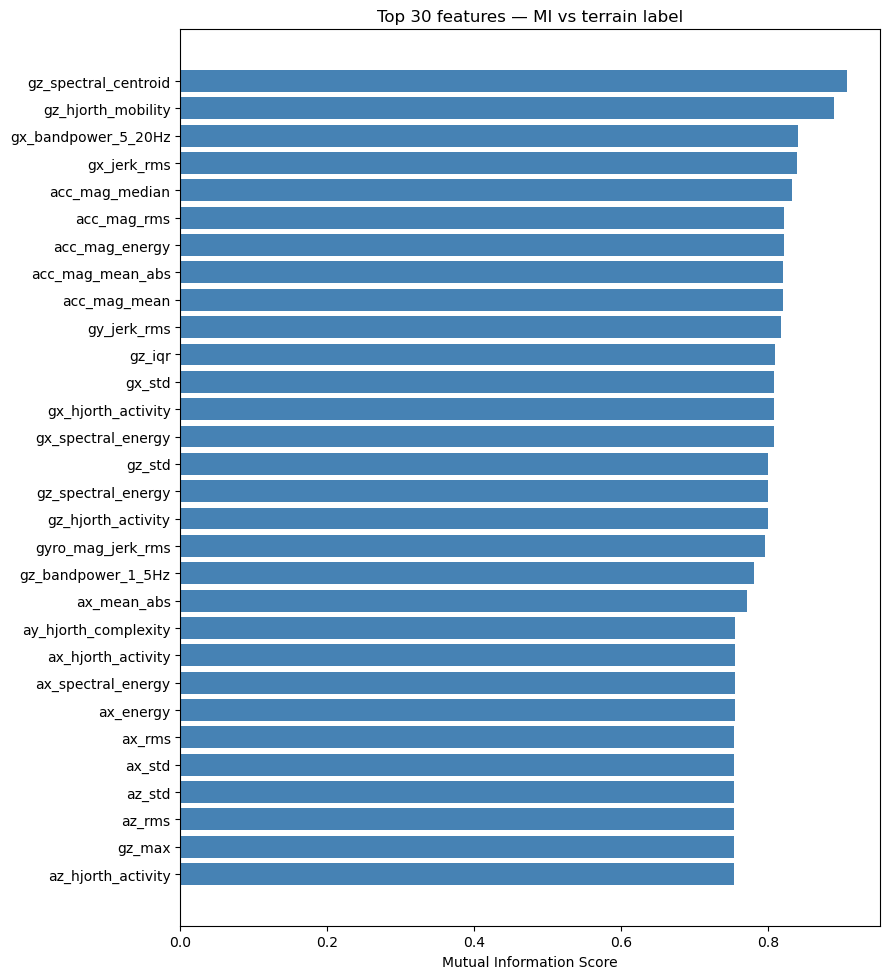


Top 25 features by MI (Dataset B):
   1. gz_spectral_centroid
   2. gz_hjorth_mobility
   3. gx_bandpower_5_20Hz
   4. gx_jerk_rms
   5. acc_mag_median
   6. acc_mag_rms
   7. acc_mag_energy
   8. acc_mag_mean_abs
   9. acc_mag_mean
  10. gy_jerk_rms
  11. gz_iqr
  12. gx_std
  13. gx_hjorth_activity
  14. gx_spectral_energy
  15. gz_std
  16. gz_spectral_energy
  17. gz_hjorth_activity
  18. gyro_mag_jerk_rms
  19. gz_bandpower_1_5Hz
  20. ax_mean_abs
  21. ay_hjorth_complexity
  22. ax_hjorth_activity
  23. ax_spectral_energy
  24. ax_energy
  25. ax_rms


In [18]:
mi_df = compute_mutual_information(
    features_df  = dataset_B_tf,
    feature_cols = feature_cols,   # full feature set
    label_col    = "label",
    n_neighbors  = 5,
    random_state = RANDOM_STATE,
    top_n        = 30,
    plot         = True,
    reports_dir  = reports_dir_B,
    show         = True,
)

# Save top-25 feature names for easy reference in 07_modelling
top_features = mi_df.head(25)["feature"].tolist()
print(f"\nTop 25 features by MI (Dataset B):")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2d}. {f}")

## Cell 7 — Mutual information on Dataset A

Compare with Dataset B — features that rank highly in **both** are robustly
terrain-discriminative regardless of speed regime.


Top 30 features by mutual information (vs 'label'):
                 feature  mi_score
    gz_spectral_centroid  0.648697
      gz_hjorth_mobility  0.621334
     gx_bandpower_5_20Hz  0.605892
             gx_jerk_rms  0.597040
            acc_mag_mean  0.587779
        acc_mag_mean_abs  0.587779
          acc_mag_energy  0.583536
             acc_mag_rms  0.583349
      gz_bandpower_1_5Hz  0.582460
          acc_mag_median  0.577771
      gy_bandpower_1_5Hz  0.569589
                  ay_rms  0.561975
                  ay_std  0.561975
      gx_hjorth_mobility  0.561694
             ay_mean_abs  0.561500
      ay_hjorth_activity  0.561195
      ay_spectral_energy  0.561195
               ay_energy  0.561195
             ay_jerk_rms  0.551057
     ay_bandpower_5_20Hz  0.544993
    ay_hjorth_complexity  0.524860
    gx_spectral_centroid  0.518343
                  ay_iqr  0.517771
                ay_range  0.515122
      gx_bandpower_1_5Hz  0.511650
acc_mag_bandpower_5_20Hz  0.494588
  

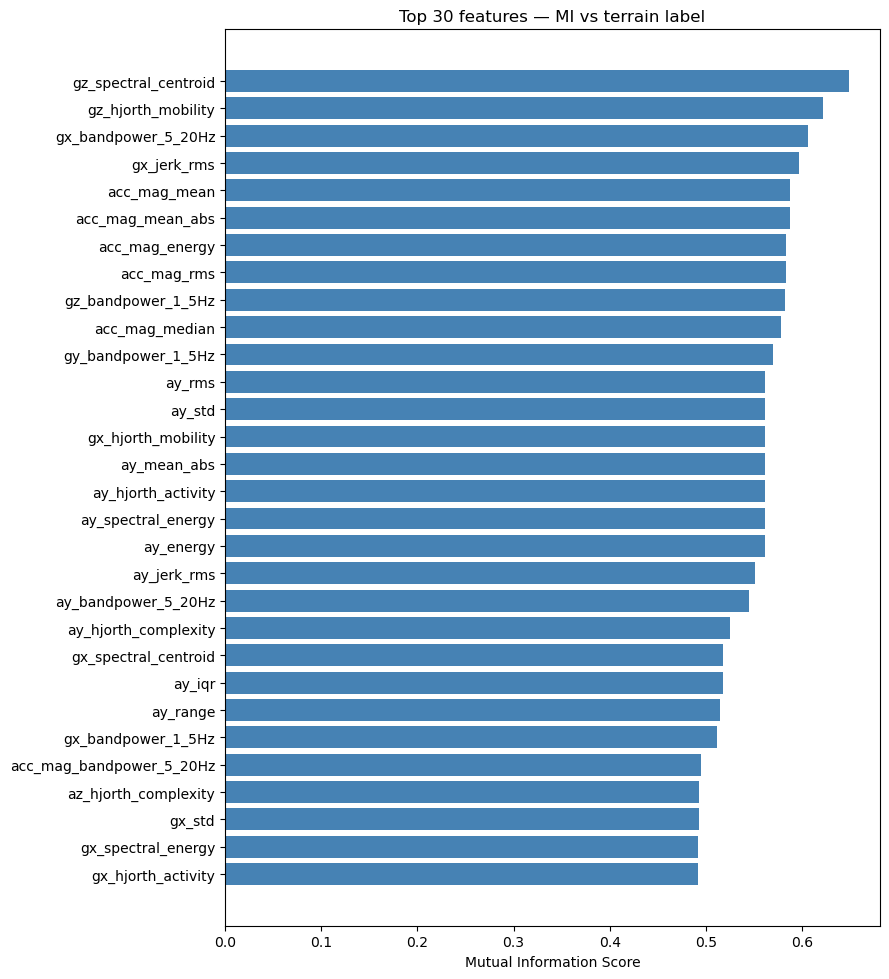


Features in top-15 for BOTH datasets (9 features):
  acc_mag_energy
  acc_mag_mean
  acc_mag_mean_abs
  acc_mag_median
  acc_mag_rms
  gx_bandpower_5_20Hz
  gx_jerk_rms
  gz_hjorth_mobility
  gz_spectral_centroid

Only in Dataset A top-15: ['ay_mean_abs', 'ay_rms', 'ay_std', 'gx_hjorth_mobility', 'gy_bandpower_1_5Hz', 'gz_bandpower_1_5Hz']
Only in Dataset B top-15: ['gx_hjorth_activity', 'gx_spectral_energy', 'gx_std', 'gy_jerk_rms', 'gz_iqr', 'gz_std']


In [19]:
mi_df_A = compute_mutual_information(
    features_df  = dataset_A_tf,
    feature_cols = feature_cols,
    label_col    = "label",
    n_neighbors  = 5,
    random_state = RANDOM_STATE,
    top_n        = 30,
    plot         = True,
    reports_dir  = reports_dir_A,
    show         = True,
)

# Compare top-15 between the two datasets
top_A = set(mi_df_A.head(15)["feature"])
top_B = set(mi_df.head(15)["feature"])
print(f"\nFeatures in top-15 for BOTH datasets ({len(top_A & top_B)} features):")
for f in sorted(top_A & top_B):
    print(f"  {f}")
print(f"\nOnly in Dataset A top-15: {sorted(top_A - top_B)}")
print(f"Only in Dataset B top-15: {sorted(top_B - top_A)}")

## Cell 8 — Correlation pruning (Dataset B)

Many features are near-identical (e.g. `rms` and `std` on a zero-mean signal are
mathematically equivalent; `energy` and `rms` are monotonically related).
Dropping them reduces model training time and the risk of instability in  
linear models without reducing predictive information.

We prune Dataset B — the dataset most likely to be used for model training.

In [20]:
CORR_THRESHOLD = 0.95   # drop one of any pair with |Pearson r| > this

dataset_B_pruned, dropped_cols = drop_high_correlation_features(
    dataset_B_tf,
    feature_cols = feature_cols,
    threshold    = CORR_THRESHOLD,
    id_cols      = ID_COLS,
)

remaining_cols = get_feature_columns(dataset_B_pruned, id_cols=ID_COLS)
print(f"\nBefore pruning : {len(feature_cols)} features")
print(f"After pruning  : {len(remaining_cols)} features")
print(f"Dropped        : {len(dropped_cols)} features")


[Correlation pruning] threshold=0.95
  Dropped 69 features:
    acc_mag_hjorth_activity
    acc_mag_hjorth_mobility
    acc_mag_iqr
    acc_mag_mean
    acc_mag_mean_abs
    acc_mag_median
    acc_mag_range
    acc_mag_rms
    acc_mag_spectral_energy
    acc_mag_std
    ax_bandpower_5_20Hz
    ax_hjorth_activity
    ax_hjorth_mobility
    ax_iqr
    ax_mean_abs
    ax_min
    ax_rms
    ax_spectral_energy
    ax_std
    ay_bandpower_40_80Hz
    ay_bandpower_5_20Hz
    ay_energy
    ay_hjorth_activity
    ay_hjorth_mobility
    ay_iqr
    ay_jerk_rms
    ay_mean_abs
    ay_min
    ay_rms
    ay_spectral_energy
    ay_std
    az_bandpower_1_5Hz
    az_bandpower_40_80Hz
    az_bandpower_5_20Hz
    az_hjorth_activity
    az_hjorth_mobility
    az_jerk_rms
    az_mean_abs
    az_rms
    az_spectral_energy
    az_std
    gx_hjorth_activity
    gx_hjorth_mobility
    gx_jerk_rms
    gx_rms
    gx_std
    gy_bandpower_40_80Hz
    gy_hjorth_activity
    gy_mean
    gy_mean_abs
    gy_min
    g

## Cell 9 — (Optional) Inspect specific terrain-pair separability

The hardest pairs to separate in this dataset are typically:
- `grass` vs `dry_dirt_track` (both firm, low vibration)
- `muddy_dirt_track` vs `dry_dirt_track` (similar texture, different wheel-ground coupling)

This cell plots the top-5 MI features as violin plots **only for these two pairs** to
check whether the features genuinely separate them.

/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is dep

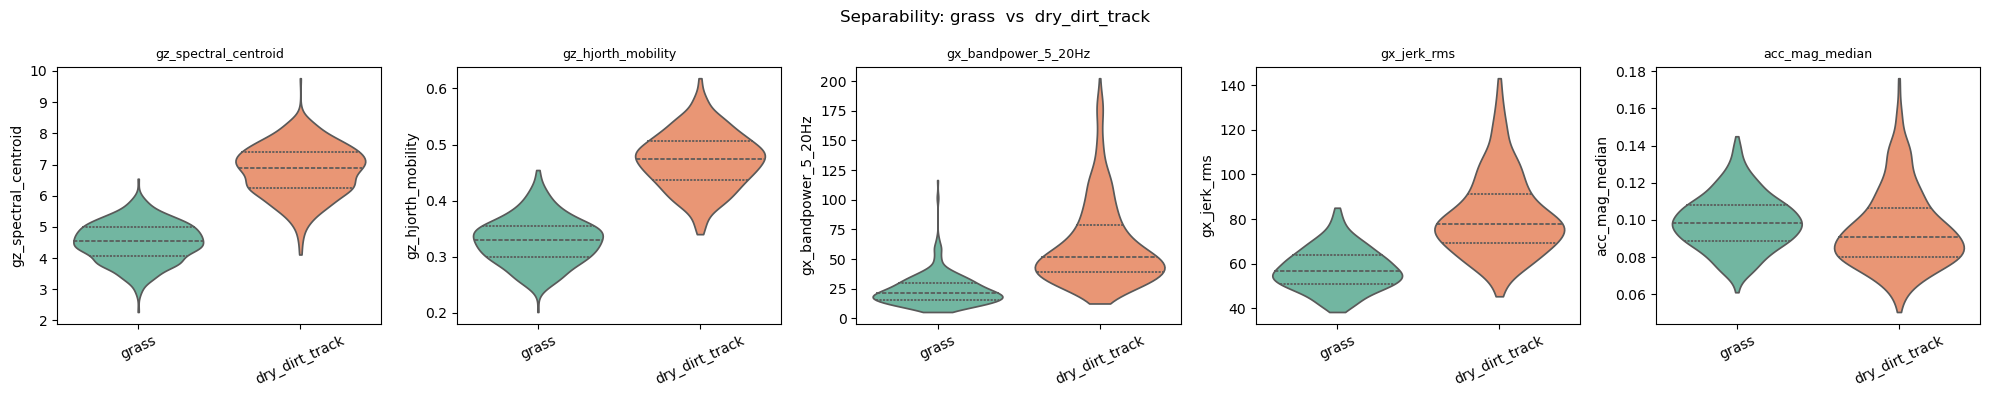

/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is dep

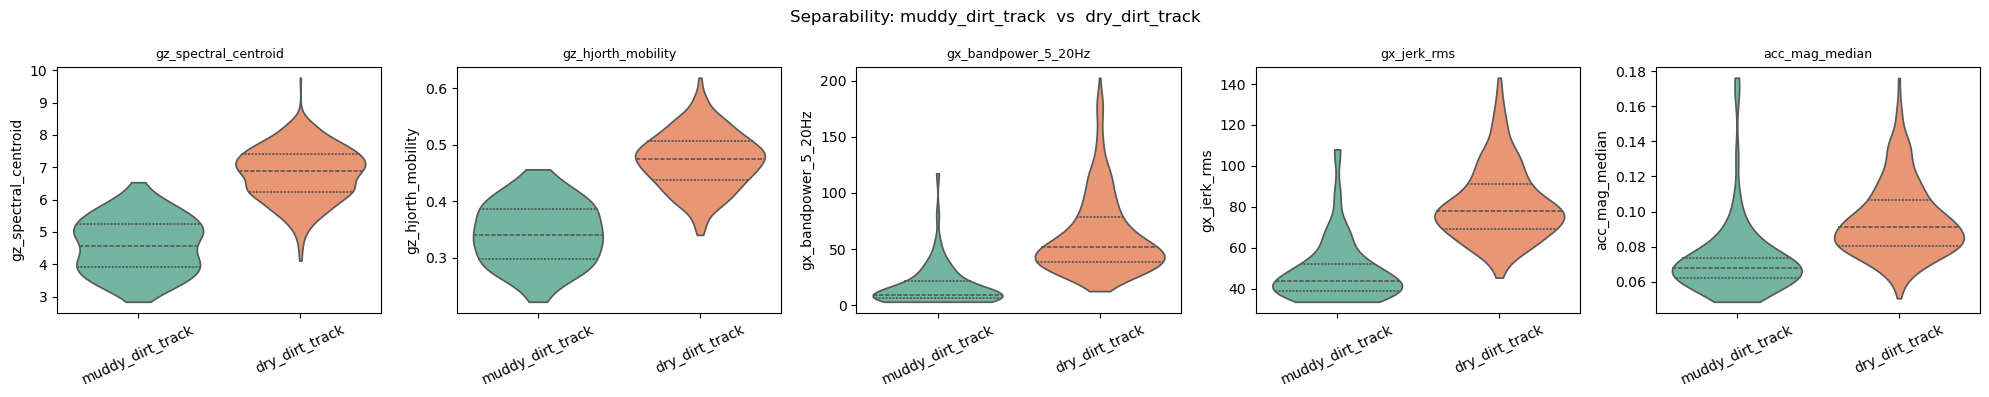

/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/wh/6d7zf7cx3632z8j44tx9fqxr0000gn/T/ipykernel_62367/3379878028.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is dep

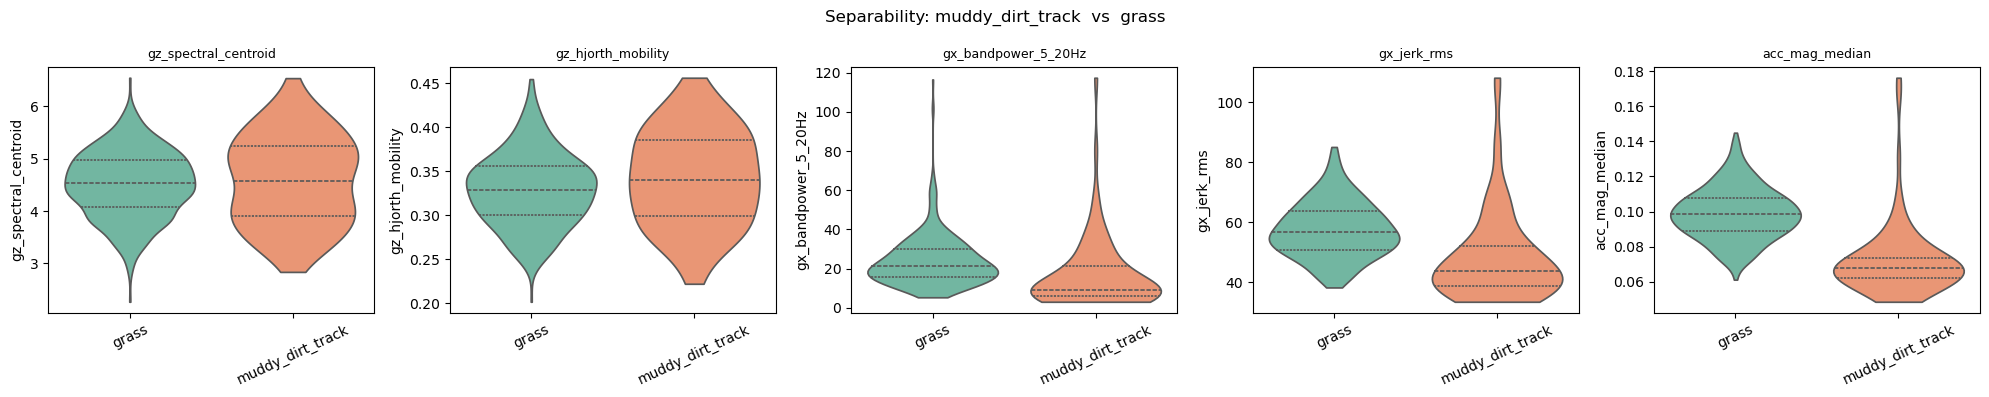

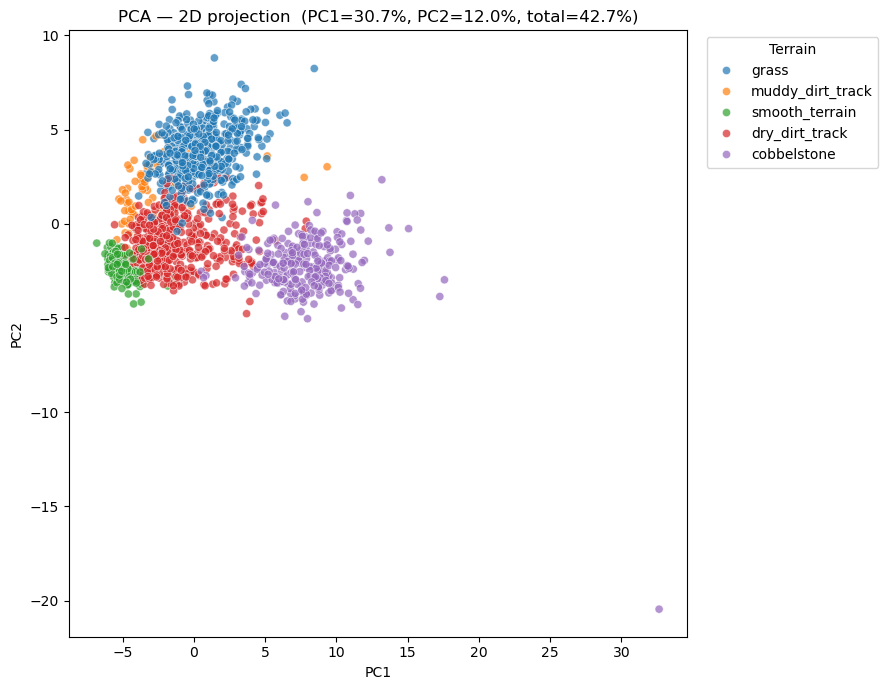

PCA explained variance: PC1=0.307, PC2=0.120, total=0.427


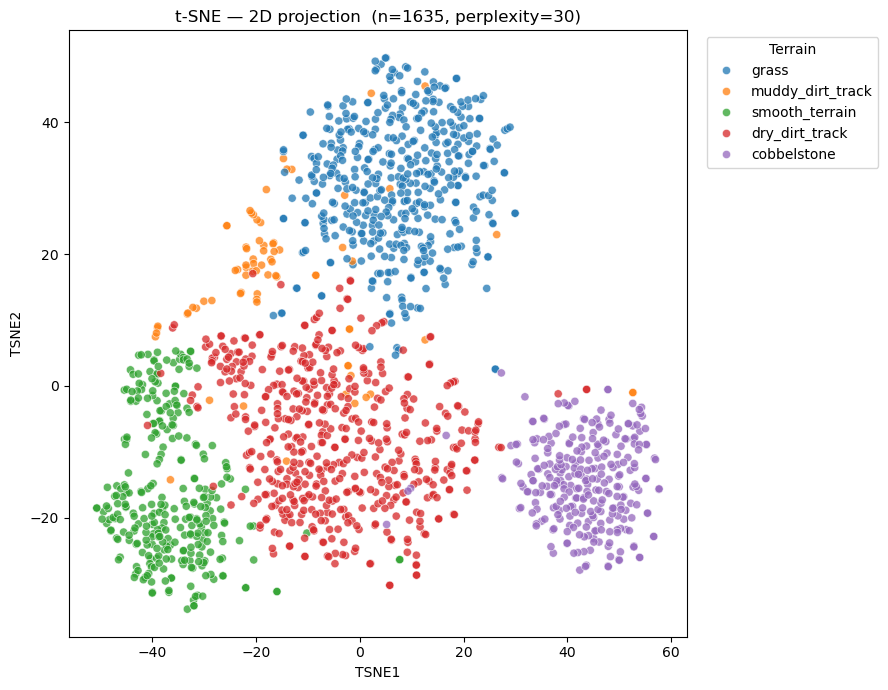

{'pca_explained_variance_ratio': array([0.30693598, 0.12031223]),
 'pca_cumulative_variance': 0.4272482092830677,
 'n_tsne_samples': 1635}

In [21]:
import seaborn as sns
from src.features import plot_pca_tsne

HARD_PAIRS = [
    ("grass",          "dry_dirt_track"),
    ("muddy_dirt_track", "dry_dirt_track"),
    ("muddy_dirt_track", "grass"),
]

# Top-5 features from Dataset B MI
top5 = mi_df.head(5)["feature"].tolist()

for cls_a, cls_b in HARD_PAIRS:
    subset = dataset_B_tf[
        dataset_B_tf["label"].isin([cls_a, cls_b])
    ]
    if subset.empty:
        print(f"No data for pair ({cls_a}, {cls_b}) — skipping.")
        continue

    fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4), sharey=False)
    fig.suptitle(f"Separability: {cls_a}  vs  {cls_b}", fontsize=12)

    for ax, feat in zip(axes, top5):
        if feat not in subset.columns:
            ax.set_visible(False)
            continue
        sns.violinplot(
            data=subset, x="label", y=feat, ax=ax,
            inner="quartile", cut=0, palette="Set2",
        )
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)

    fig.tight_layout()
    plt.show()


eda_feat_cols_B_pruned = get_eda_feature_columns(dataset_B_pruned, id_cols=ID_COLS)
plot_pca_tsne(features_df=dataset_B_pruned, feature_cols=eda_feat_cols_B_pruned, label_col="label")



## Cell 10 — Save outputs

| File | Contents |
|------|----------|
| `dataset_A_features.csv` | All windows, log-transformed, **not** pruned |
| `dataset_B_features.csv` | Speed-controlled, log-transformed, correlation-pruned |

Both files are ready to be loaded directly in `07_modelling.ipynb`.

In [22]:
out_dir = PROJECT_ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

path_A = out_dir / "dataset_A_features.csv"
path_B = out_dir / "dataset_B_features.csv"

dataset_A_tf.to_csv(path_A, index=False)
dataset_B_pruned.to_csv(path_B, index=False)

print("Saved:")
print(f"  Dataset A : {path_A}  {dataset_A_tf.shape}")
print(f"  Dataset B : {path_B}  {dataset_B_pruned.shape}")
print(f"\nTop-25 MI features (Dataset B) for 07_modelling:")
print(top_features)
print("\nReady for 07_modelling.ipynb ✓")

Saved:
  Dataset A : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/dataset_A_features.csv  (2346, 220)
  Dataset B : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/processed/dataset_B_features.csv  (1635, 151)

Top-25 MI features (Dataset B) for 07_modelling:
['gz_spectral_centroid', 'gz_hjorth_mobility', 'gx_bandpower_5_20Hz', 'gx_jerk_rms', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_energy', 'acc_mag_mean_abs', 'acc_mag_mean', 'gy_jerk_rms', 'gz_iqr', 'gx_std', 'gx_hjorth_activity', 'gx_spectral_energy', 'gz_std', 'gz_spectral_energy', 'gz_hjorth_activity', 'gyro_mag_jerk_rms', 'gz_bandpower_1_5Hz', 'ax_mean_abs', 'ay_hjorth_complexity', 'ax_hjorth_activity', 'ax_spectral_energy', 'ax_energy', 'ax_rms']

Ready for 07_modelling.ipynb ✓
